In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

print("✅ Libraries imported successfully!")
print(f"Pandas version: {pd.__version__}")

✅ Libraries imported successfully!
Pandas version: 3.0.2


In [2]:
import os

# Try to load real data
file_path = '../data/Online Retail.xlsx'

if os.path.exists(file_path):
    df = pd.read_excel(file_path)
    print("✅ Loaded real Online Retail dataset!")
    print(f"Shape: {df.shape}")
else:
    # Create sample data if file not found
    print("⚠️ Real dataset not found. Creating sample data...")
    
    np.random.seed(42)
    n_customers = 5000
    
    df_sample = pd.DataFrame({
        'CustomerID': np.random.randint(10000, 20000, n_customers),
        'InvoiceDate': pd.date_range('2020-01-01', '2023-12-31', periods=n_customers),
        'Quantity': np.random.randint(1, 100, n_customers),
        'UnitPrice': np.random.uniform(1, 100, n_customers),
        'Country': np.random.choice(['UK', 'Germany', 'France', 'USA'], n_customers)
    })
    df_sample['TotalPrice'] = df_sample['Quantity'] * df_sample['UnitPrice']
    df = df_sample
    print(f"✅ Sample data created! Shape: {df.shape}")

df.head()

⚠️ Real dataset not found. Creating sample data...
✅ Sample data created! Shape: (5000, 6)


,CustomerID,InvoiceDate,Quantity,UnitPrice,Country,TotalPrice
0,17270,2020-01-01 00:00:00.000000,36,57.775685,UK,2079.924647
1,10860,2020-01-01 07:00:33.846769,22,22.309138,UK,490.801041
2,15390,2020-01-01 14:01:07.693538,78,86.300870,France,6731.467865
3,15191,2020-01-01 21:01:41.540308,80,94.276360,UK,7542.108800
4,15734,2020-01-02 04:02:15.387077,61,52.330805,USA,3192.179076


In [3]:
print("=" * 50)
print("DATA CLEANING")
print("=" * 50)

# Check missing values
print(f"\nMissing values:\n{df.isnull().sum()}")

# Remove negative quantities (returns)
if 'Quantity' in df.columns:
    before = len(df)
    df = df[df['Quantity'] > 0]
    print(f"\nRemoved negative quantities: {before - len(df)} rows")

# Remove cancelled invoices
if 'Invoice' in df.columns:
    before = len(df)
    df = df[~df['Invoice'].astype(str).str.contains('C', na=False)]
    print(f"Removed cancelled invoices: {before - len(df)} rows")

# Remove rows without CustomerID
before = len(df)
df = df.dropna(subset=['CustomerID'])
print(f"Removed rows without CustomerID: {before - len(df)} rows")

# Convert CustomerID to int
df['CustomerID'] = df['CustomerID'].astype(int)

print(f"\n✅ Cleaned data shape: {df.shape}")

DATA CLEANING

Missing values:
CustomerID     0
InvoiceDate    0
Quantity       0
UnitPrice      0
Country        0
TotalPrice     0
dtype: int64

Removed negative quantities: 0 rows
Removed rows without CustomerID: 0 rows

✅ Cleaned data shape: (5000, 6)


In [12]:
print("=" * 50)
print("RFM ANALYSIS")
print("=" * 50)

# Reference date (day after last purchase)
reference_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)
print(f"Reference date: {reference_date.date()}")

# Calculate RFM using simple method
rfm_list = []

for customer_id in df['CustomerID'].unique():
    customer_data = df[df['CustomerID'] == customer_id]
    
    # Recency: days since last purchase
    last_date = customer_data['InvoiceDate'].max()
    recency = (reference_date - last_date).days
    
    # Frequency: number of purchases
    frequency = len(customer_data)
    
    # Monetary: total spent
    monetary = customer_data['TotalPrice'].sum()
    
    rfm_list.append([customer_id, recency, frequency, monetary])

# Create DataFrame
rfm = pd.DataFrame(rfm_list, columns=['CustomerID', 'Recency', 'Frequency', 'Monetary'])

print(f"\n✅ RFM Data Shape: {rfm.shape}")
print(f"Total customers: {len(rfm):,}")
print("\nRFM Statistics:")
print(rfm.describe())

print("\nFirst 10 customers:")
print(rfm.head(10))

RFM ANALYSIS
Reference date: 2024-01-01

✅ RFM Data Shape: (3885, 4)
Total customers: 3,885

RFM Statistics:
         CustomerID      Recency    Frequency      Monetary
count   3885.000000  3885.000000  3885.000000   3885.000000
mean   14954.952638   668.622651     1.287001   3252.430547
std     2870.807170   419.674503     0.556997   2801.387716
min    10001.000000     1.000000     1.000000      1.015617
25%    12440.000000   301.000000     1.000000    971.985847
50%    14966.000000   638.000000     1.000000   2576.170510
75%    17385.000000  1021.000000     1.000000   4878.992329
max    19998.000000  1461.000000     5.000000  21759.070450

First 10 customers:
   CustomerID  Recency  Frequency     Monetary
0       17270     1461          1  2079.924647
1       10860     1460          1   490.801041
2       15390     1012          2  6810.669067
3       15191     1460          1  7542.108800
4       15734     1459          1  3192.179076
5       16265       94          2  7592.098491
6

In [15]:
print("=" * 50)
print("CREATING RFM SCORES")
print("=" * 50)

# Create scores using rank method (more reliable)
def create_scores_fixed(rfm):
    # Recency Score (lower recency is better)
    rfm['R_Score'] = pd.qcut(rfm['Recency'].rank(method='first'), 4, labels=['4', '3', '2', '1'])
    
    # Frequency Score (higher is better)
    rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), 4, labels=['1', '2', '3', '4'])
    
    # Monetary Score (higher is better)
    rfm['M_Score'] = pd.qcut(rfm['Monetary'].rank(method='first'), 4, labels=['1', '2', '3', '4'])
    
    # Convert to numeric for calculations
    rfm['R_Num'] = rfm['R_Score'].astype(int)
    rfm['F_Num'] = rfm['F_Score'].astype(int)
    rfm['M_Num'] = rfm['M_Score'].astype(int)
    
    # Combined score
    rfm['RFM_Numeric'] = rfm['R_Num'] + rfm['F_Num'] + rfm['M_Num']
    rfm['RFM_Score'] = rfm['R_Score'].astype(str) + rfm['F_Score'].astype(str) + rfm['M_Score'].astype(str)
    
    return rfm

rfm = create_scores_fixed(rfm)

print("✅ RFM Scores Created!")
print("\nScore Distribution:")
print(rfm['RFM_Numeric'].value_counts().sort_index())

print("\nFirst 10 customers with scores:")
print(rfm[['CustomerID', 'Recency', 'Frequency', 'Monetary', 'R_Score', 'F_Score', 'M_Score', 'RFM_Numeric']].head(10))

CREATING RFM SCORES
✅ RFM Scores Created!

Score Distribution:
RFM_Numeric
3     293
4     285
5     457
6     436
7     379
8     535
9     470
10    473
11    361
12    196
Name: count, dtype: int64

First 10 customers with scores:
   CustomerID  Recency  Frequency     Monetary R_Score F_Score M_Score  \
0       17270     1461          1  2079.924647       1       1       2   
1       10860     1460          1   490.801041       1       1       1   
2       15390     1012          2  6810.669067       2       4       4   
3       15191     1460          1  7542.108800       1       1       4   
4       15734     1459          1  3192.179076       1       1       3   
5       16265       94          2  7592.098491       4       4       4   
6       10466     1459          1  2151.283056       1       1       2   
7       14426      352          3  7959.594287       3       4       4   
8       15578       62          2  3916.223022       4       4       3   
9       18322     1458    

In [16]:
print("=" * 50)
print("CUSTOMER SEGMENTATION")
print("=" * 50)

# Define segments
def get_segment(row):
    r = row['R_Num']
    f = row['F_Num']
    m = row['M_Num']
    
    if r >= 3 and f >= 3 and m >= 3:
        return 'VIP'
    elif r >= 3 and f >= 2:
        return 'Loyal'
    elif r <= 2 and f >= 3:
        return 'At-Risk'
    elif r >= 3 and f == 1:
        return 'New'
    elif r <= 2 and f <= 2:
        return 'Inactive'
    else:
        return 'Regular'

rfm['Segment'] = rfm.apply(get_segment, axis=1)

segment_counts = rfm['Segment'].value_counts()
for segment, count in segment_counts.items():
    percentage = (count / len(rfm)) * 100
    print(f"{segment}: {count:,} customers ({percentage:.1f}%)")

# Save to CSV
import os
os.makedirs('../data', exist_ok=True)
rfm.to_csv('../data/rfm_data.csv', index=False)
print("\n✅ RFM data saved to: data/rfm_data.csv")

CUSTOMER SEGMENTATION
Inactive: 1,666 customers (42.9%)
Loyal: 992 customers (25.5%)
VIP: 951 customers (24.5%)
At-Risk: 276 customers (7.1%)

✅ RFM data saved to: data/rfm_data.csv


✅ Chart saved: images/segment_distribution.png


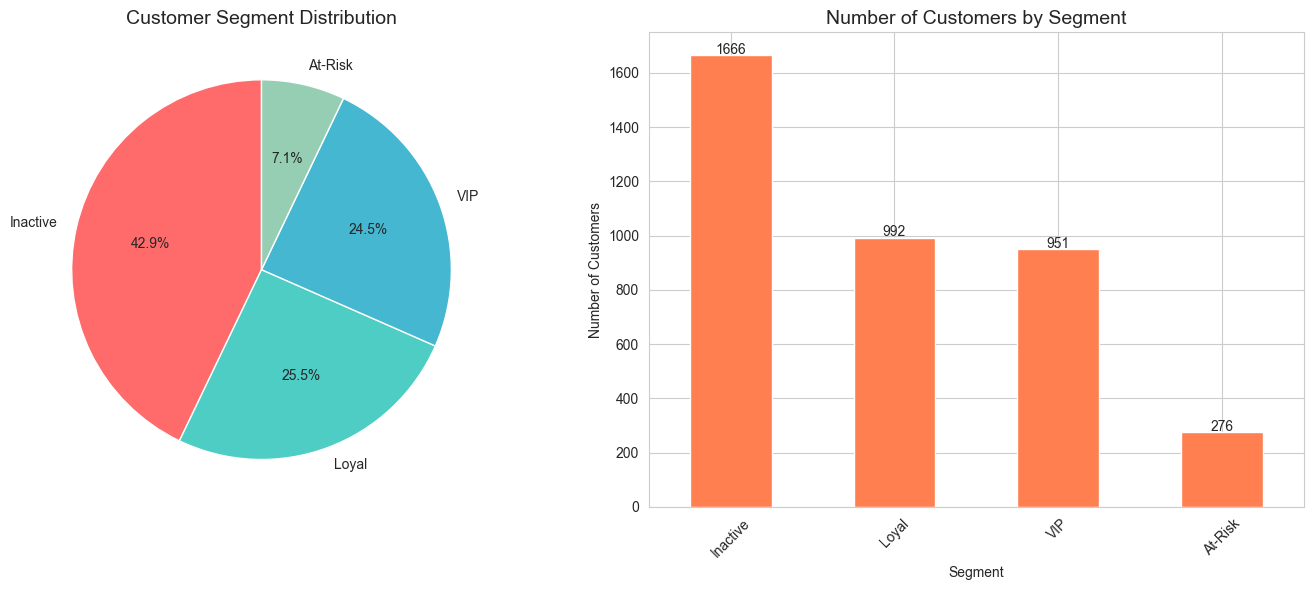

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Create folder for images
os.makedirs('../images', exist_ok=True)

# Segment distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Pie chart
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4', '#FFEAA7', '#DDA0DD']
segment_counts.plot(kind='pie', ax=axes[0], autopct='%1.1f%%', colors=colors, startangle=90)
axes[0].set_title('Customer Segment Distribution', fontsize=14)
axes[0].set_ylabel('')

# Bar chart
segment_counts.plot(kind='bar', ax=axes[1], color='coral')
axes[1].set_title('Number of Customers by Segment', fontsize=14)
axes[1].set_xlabel('Segment')
axes[1].set_ylabel('Number of Customers')
axes[1].tick_params(axis='x', rotation=45)

# Add value labels on bars
for i, v in enumerate(segment_counts.values):
    axes[1].text(i, v + 5, str(v), ha='center', fontsize=10)

plt.tight_layout()
plt.savefig('../images/segment_distribution.png', dpi=100)
print("✅ Chart saved: images/segment_distribution.png")
plt.show()

SEGMENT PROFILES
          Avg Recency (days)  Avg Frequency  Avg Monetary ($)  Customer Count
Segment                                                                      
VIP                   271.24           1.70           5819.61             951
At-Risk               886.20           2.11           5200.65             276
Inactive             1054.21           1.00           2461.99            1666
Loyal                 341.48           1.15           1576.80             992
✅ Chart saved: images/segment_profiles.png


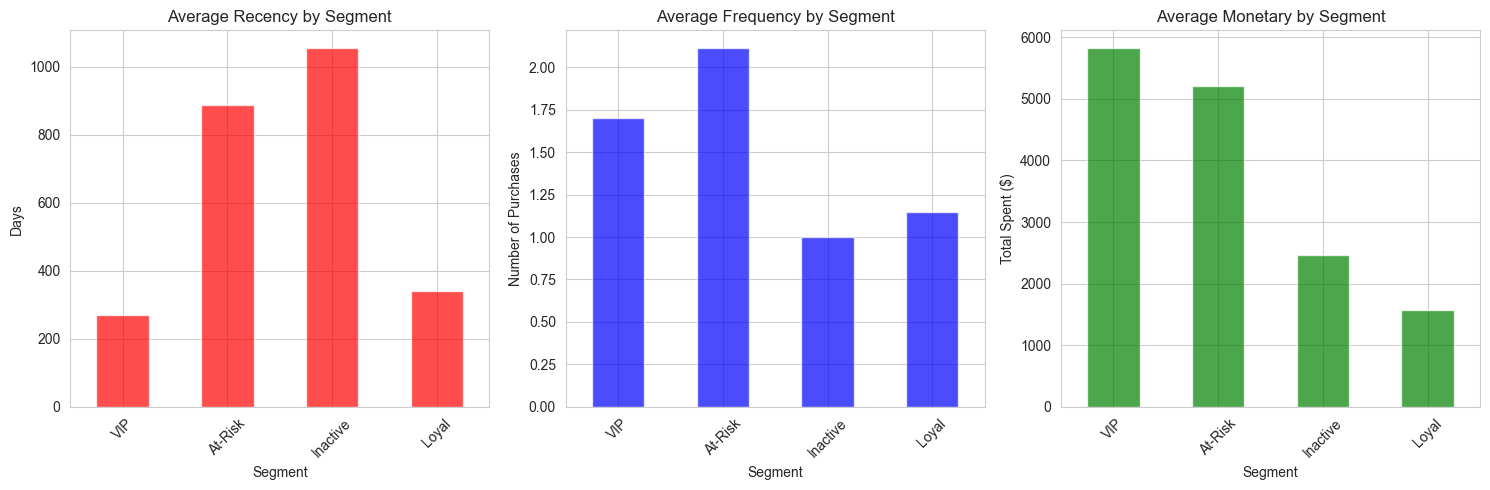

In [18]:
# Calculate segment profiles
segment_profile = rfm.groupby('Segment').agg({
    'Recency': 'mean',
    'Frequency': 'mean',
    'Monetary': 'mean',
    'CustomerID': 'count'
}).round(2)

segment_profile.columns = ['Avg Recency (days)', 'Avg Frequency', 'Avg Monetary ($)', 'Customer Count']
segment_profile = segment_profile.sort_values('Avg Monetary ($)', ascending=False)

print("=" * 50)
print("SEGMENT PROFILES")
print("=" * 50)
print(segment_profile)

# Visualize segment profiles
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Recency chart
segment_profile['Avg Recency (days)'].plot(kind='bar', ax=axes[0], color='red', alpha=0.7)
axes[0].set_title('Average Recency by Segment', fontsize=12)
axes[0].set_ylabel('Days')
axes[0].tick_params(axis='x', rotation=45)

# Frequency chart
segment_profile['Avg Frequency'].plot(kind='bar', ax=axes[1], color='blue', alpha=0.7)
axes[1].set_title('Average Frequency by Segment', fontsize=12)
axes[1].set_ylabel('Number of Purchases')
axes[1].tick_params(axis='x', rotation=45)

# Monetary chart
segment_profile['Avg Monetary ($)'].plot(kind='bar', ax=axes[2], color='green', alpha=0.7)
axes[2].set_title('Average Monetary by Segment', fontsize=12)
axes[2].set_ylabel('Total Spent ($)')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('../images/segment_profiles.png', dpi=100)
print("✅ Chart saved: images/segment_profiles.png")
plt.show()

In [19]:
print("=" * 60)
print("💡 BUSINESS RECOMMENDATIONS BY SEGMENT")
print("=" * 60)

recommendations = {
    'VIP': [
        "✓ Send exclusive loyalty rewards and early access to new products",
        "✓ Offer premium membership with free shipping",
        "✓ Personal thank you notes and birthday gifts",
        "✓ Invite to VIP focus groups for product feedback"
    ],
    'Loyal': [
        "✓ Implement referral program (give $20, get $20)",
        "✓ Cross-sell complementary products",
        "✓ Offer loyalty points that never expire",
        "✓ Send personalized product recommendations"
    ],
    'At-Risk': [
        "✓ Send re-engagement emails with special discount (20-30%)",
        "✓ Offer win-back campaigns: 'We miss you'",
        "✓ Send customer satisfaction survey",
        "✓ Remind them of unused loyalty points"
    ],
    'New': [
        "✓ Welcome series emails with onboarding education",
        "✓ First-purchase discount for next order (15%)",
        "✓ Product tutorials and usage guides",
        "✓ Ask for product reviews after 14 days"
    ],
    'Regular': [
        "✓ Nurture with consistent email communication",
        "✓ Offer bundle deals to increase order value",
        "✓ Highlight best-selling products",
        "✓ Send seasonal promotions"
    ],
    'Inactive': [
        "✓ Last chance win-back campaign with 30% discount",
        "✓ Ask if they want to update preferences",
        "✓ Re-target with social media ads",
        "✓ Consider removing from active lists"
    ]
}

for segment in segment_counts.index:
    if segment in recommendations:
        print(f"\n{'='*40}")
        print(f"🎯 {segment} CUSTOMERS ({segment_counts[segment]:,} customers - {segment_counts[segment]/len(rfm)*100:.1f}%)")
        print(f"{'='*40}")
        for action in recommendations[segment]:
            print(action)

💡 BUSINESS RECOMMENDATIONS BY SEGMENT

🎯 Inactive CUSTOMERS (1,666 customers - 42.9%)
✓ Last chance win-back campaign with 30% discount
✓ Ask if they want to update preferences
✓ Re-target with social media ads
✓ Consider removing from active lists

🎯 Loyal CUSTOMERS (992 customers - 25.5%)
✓ Implement referral program (give $20, get $20)
✓ Cross-sell complementary products
✓ Offer loyalty points that never expire
✓ Send personalized product recommendations

🎯 VIP CUSTOMERS (951 customers - 24.5%)
✓ Send exclusive loyalty rewards and early access to new products
✓ Offer premium membership with free shipping
✓ Personal thank you notes and birthday gifts
✓ Invite to VIP focus groups for product feedback

🎯 At-Risk CUSTOMERS (276 customers - 7.1%)
✓ Send re-engagement emails with special discount (20-30%)
✓ Offer win-back campaigns: 'We miss you'
✓ Send customer satisfaction survey
✓ Remind them of unused loyalty points


In [20]:
from datetime import datetime

os.makedirs('../reports', exist_ok=True)

# Calculate additional metrics
total_revenue = rfm['Monetary'].sum()
avg_customer_value = rfm['Monetary'].mean()
top_segment = segment_profile.index[0]
top_segment_value = segment_profile.iloc[0]['Avg Monetary ($)']

report = f"""
========================================
     CUSTOMER SEGMENTATION REPORT
========================================

Analysis Date: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}
Total Customers Analyzed: {len(rfm):,}

========================================
SEGMENT SUMMARY
========================================

"""

for segment in segment_profile.index:
    row = segment_profile.loc[segment]
    percentage = (segment_counts[segment] / len(rfm)) * 100
    report += f"""
┌─────────────────────────────────────────────────┐
│  {segment} CUSTOMERS ({segment_counts[segment]:,} customers - {percentage:.1f}%)
├─────────────────────────────────────────────────┤
│  • Average Recency:  {row['Avg Recency (days)']:.0f} days
│  • Average Frequency: {row['Avg Frequency']:.1f} purchases
│  • Average Monetary:  ${row['Avg Monetary ($)']:,.2f}
└─────────────────────────────────────────────────┘
"""

report += f"""
========================================
BUSINESS IMPACT
========================================

Total Customer Value:     ${total_revenue:,.2f}
Average Customer Value:   ${avg_customer_value:,.2f}
Top Segment by Value:     {top_segment}
Top Segment Avg Value:    ${top_segment_value:,.2f} per customer

========================================
RECOMMENDATIONS PRIORITY
========================================

🔴 HIGH PRIORITY (Immediate):
   • VIP and Loyal segments - Maintain and reward
   • At-Risk segment - Re-engagement campaigns

🟡 MEDIUM PRIORITY (1-3 months):
   • New customers - Onboarding and education
   • Regular customers - Nurture campaigns

🟢 LOW PRIORITY (3-6 months):
   • Inactive customers - Win-back campaigns

========================================
END OF REPORT
========================================
"""

# Save report
with open('../reports/segmentation_report.txt', 'w', encoding='utf-8') as f:
    f.write(report)

print("✅ Report saved: reports/segmentation_report.txt")
print("\n" + "=" * 50)
print("REPORT PREVIEW:")
print("=" * 50)
print(report[:800])
print("\n... (full report saved to file)")

✅ Report saved: reports/segmentation_report.txt

REPORT PREVIEW:

     CUSTOMER SEGMENTATION REPORT

Analysis Date: 2026-05-11 11:59:06
Total Customers Analyzed: 3,885

SEGMENT SUMMARY


┌─────────────────────────────────────────────────┐
│  VIP CUSTOMERS (951 customers - 24.5%)
├─────────────────────────────────────────────────┤
│  • Average Recency:  271 days
│  • Average Frequency: 1.7 purchases
│  • Average Monetary:  $5,819.61
└─────────────────────────────────────────────────┘

┌─────────────────────────────────────────────────┐
│  At-Risk CUSTOMERS (276 customers - 7.1%)
├─────────────────────────────────────────────────┤
│  • Average Recency:  886 days
│  • Average Frequency: 2.1 purc

... (full report saved to file)


In [21]:
# Prepare data for interactive dashboard
dashboard_data = rfm[['CustomerID', 'Recency', 'Frequency', 'Monetary', 'Segment', 
                       'R_Score', 'F_Score', 'M_Score', 'RFM_Numeric']].copy()

# Save to CSV
dashboard_data.to_csv('../dashboard/customer_data.csv', index=False)
print("✅ Dashboard data saved: dashboard/customer_data.csv")
print(f"Shape: {dashboard_data.shape}")
print("\nFirst 5 rows:")
print(dashboard_data.head())

✅ Dashboard data saved: dashboard/customer_data.csv
Shape: (3885, 9)

First 5 rows:
   CustomerID  Recency  Frequency     Monetary   Segment R_Score F_Score  \
0       17270     1461          1  2079.924647  Inactive       1       1   
1       10860     1460          1   490.801041  Inactive       1       1   
2       15390     1012          2  6810.669067   At-Risk       2       4   
3       15191     1460          1  7542.108800  Inactive       1       1   
4       15734     1459          1  3192.179076  Inactive       1       1   

  M_Score  RFM_Numeric  
0       2            4  
1       1            3  
2       4           10  
3       4            6  
4       3            5  
